In [ ]:
!pip install neuraloperator

Operator Being Learned

In contrast to the PINN, which trains for learning the solution of one particular PDE, the Fourier Neural Operator learns the solution operator that takes an initial state as input and produces a solution at some future time.

For the 1D Burgers' equation, the operator being learned is

G:u
0
	​

(x)⟶u(x,T)

where:

u
0
	​

(x) is the initial state.
u(x,T) is the solution of the Burgers' equation at the terminal time T.

The goal of FNO is to learn this operator such that once it is trained, it could predict the output for previously unseen initial states.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

import torch
from torch.utils.data import TensorDataset, DataLoader
from neuralop.models import FNO

In [23]:
# Spatial domain
L = 1.0
Nx = 128

x = np.linspace(0, L, Nx, endpoint=False)
dx = L / Nx

# Time domain
T = 1.0

# Viscosity
nu = 0.01

In [24]:
# Initial conditions are sampled from a Gaussian Random Field with an RBF covariance kernel.
def generate_grf(x, length_scale=0.2):

    N = len(x)

    X1, X2 = np.meshgrid(x, x)

    K = np.exp(
        -((X1 - X2) ** 2)
        / (2 * length_scale**2)
    )

    # Numerical stability
    K += 1e-8 * np.eye(N)

    u0 = np.random.multivariate_normal(
        mean=np.zeros(N),
        cov=K,
    )

    # Normalize
    u0 /= np.max(np.abs(u0))

    return u0

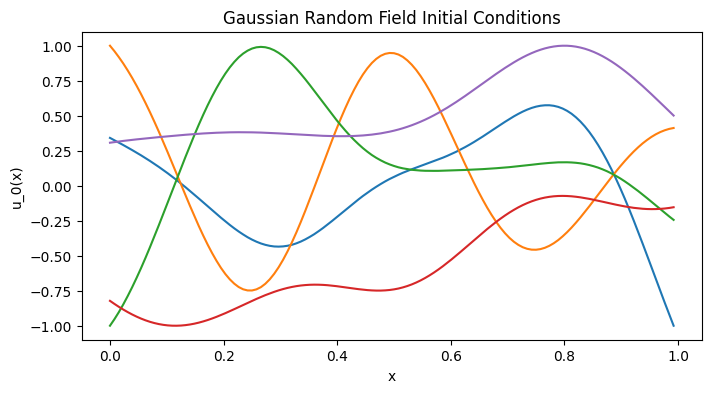

In [25]:
plt.figure(figsize=(8,4))

for _ in range(5):
    plt.plot(x, generate_grf(x))

plt.title("Gaussian Random Field Initial Conditions")
plt.xlabel("x")
plt.ylabel(r"u_0(x)")
plt.show()

In [26]:
from scipy.integrate import solve_ivp

def burgers_rhs(t, u, nu, dx):
    """
    RHS of Burgers equation:
        u_t + u*u_x = nu*u_xx
    using periodic finite differences.
    """

    u_x = (np.roll(u, -1) - np.roll(u, 1)) / (2 * dx)

    u_xx = (np.roll(u, -1) - 2*u + np.roll(u, 1)) / (dx**2)

    return -u * u_x + nu * u_xx


def solve_burgers(u0, nu=0.01, T=1.0):

    sol = solve_ivp(
        burgers_rhs,
        (0, T),
        u0,
        args=(nu, dx),
        method="RK45",
        t_eval=np.linspace(0, T, 101),
    )

    return sol.y.T

(101, 128)


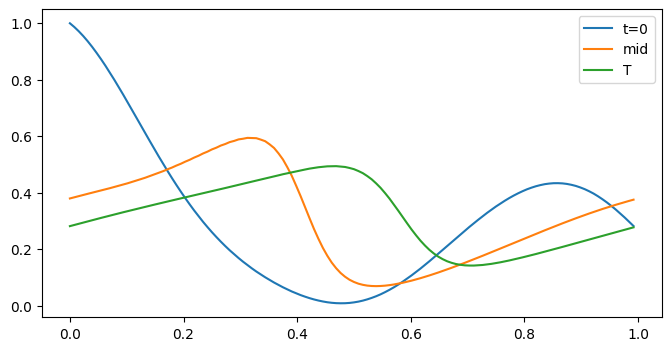

In [27]:
u0 = generate_grf(x)

trajectory = solve_burgers(u0)

print(trajectory.shape)

plt.figure(figsize=(8,4))

plt.plot(x, trajectory[0], label="t=0")
plt.plot(x, trajectory[50], label="mid")
plt.plot(x, trajectory[-1], label="T")

plt.legend()
plt.show()

In [28]:
N_train = 1000
N_test = 200

X_train = np.zeros((N_train, Nx))
Y_train = np.zeros((N_train, Nx))
nu_train = np.zeros(N_train)

for i in range(N_train):
    u0 = generate_grf(x)
    nu_i = np.random.uniform(0.01, 0.1)
    trajectory = solve_burgers(u0, nu=nu_i, T=1.0)
    X_train[i] = trajectory[0]
    Y_train[i] = trajectory[-1]
    nu_train[i] = nu_i

X_test = np.zeros((N_test, Nx))
Y_test = np.zeros((N_test, Nx))
nu_test_arr = np.zeros(N_test)

for i in range(N_test):
    u0 = generate_grf(x)
    nu_i = np.random.uniform(0.01, 0.1)
    trajectory = solve_burgers(u0, nu=nu_i, T=1.0)
    X_test[i] = trajectory[0]
    Y_test[i] = trajectory[-1]
    nu_test_arr[i] = nu_i

In [29]:
print(X_train.shape)
print(Y_train.shape)

print(X_test.shape)
print(Y_test.shape)

(1000, 128)
(1000, 128)
(200, 128)
(200, 128)


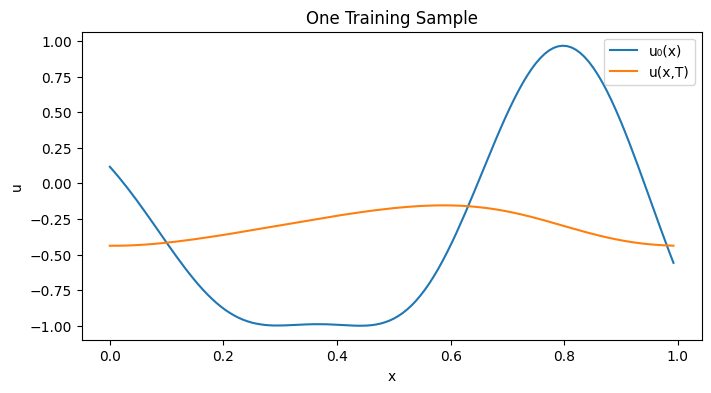

In [ ]:
idx = np.random.randint(N_train)

plt.figure(figsize=(8,4))

plt.plot(x, X_train[idx], label="u₀(x)")
plt.plot(x, Y_train[idx], label="u(x,T)")

plt.legend()
plt.xlabel("x")
plt.ylabel("u")
plt.title("One Training Sample")
plt.show()

In [31]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

In [32]:
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
Y_train = torch.tensor(Y_train, dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
Y_test  = torch.tensor(Y_test, dtype=torch.float32).unsqueeze(1)

nu_train_ch = torch.tensor(nu_train, dtype=torch.float32).view(-1, 1, 1).expand(-1, 1, Nx)
nu_test_ch  = torch.tensor(nu_test_arr, dtype=torch.float32).view(-1, 1, 1).expand(-1, 1, Nx)

X_train = torch.cat([X_train, nu_train_ch], dim=1)   # (N,2,Nx)
X_test  = torch.cat([X_test, nu_test_ch], dim=1)

print(X_train.shape)

torch.Size([1000, 2, 128])


/tmp/ipykernel_521/438636288.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)   # (N,1,Nx)


In [33]:
batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=batch_size,
    shuffle=False,
)

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [35]:
from neuralop.models import FNO

model = FNO(
    n_modes=(24,),
    in_channels=2,
    out_channels=1,
    hidden_channels=64,
    n_layers=4,
    lifting_channel_ratio=2,
    projection_channel_ratio=2,
).to(device)

criterion = torch.nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

In [36]:
epochs = 100

train_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(x_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:

        print(f"Epoch {epoch+1}: {epoch_loss:.6f}")


Epoch 10: 0.002225
Epoch 20: 0.002132
Epoch 30: 0.002029
Epoch 40: 0.000425
Epoch 50: 0.000115
Epoch 60: 0.000113
Epoch 70: 0.000049
Epoch 80: 0.000035
Epoch 90: 0.000087
Epoch 100: 0.000056


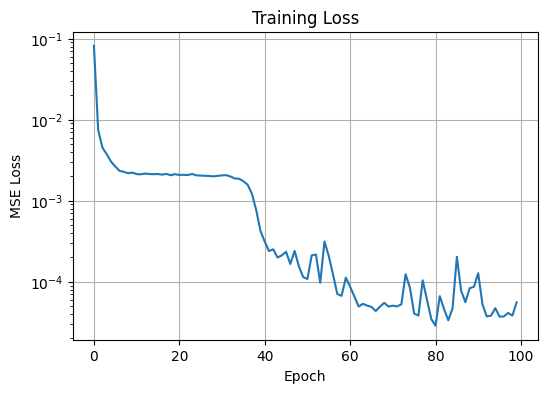

In [37]:
plt.figure(figsize=(6,4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale("log")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [38]:
model.eval()

predictions = []

with torch.no_grad():

    for x_batch, _ in test_loader:

        x_batch = x_batch.to(device)

        pred = model(x_batch)

        predictions.append(pred.cpu())

predictions = torch.cat(predictions, dim=0)

error = torch.norm(predictions - Y_test) / torch.norm(Y_test)

print("Relative L2 Error =", error.item())

Relative L2 Error = 0.028372222557663918


In [39]:

nus = [0.001, 0.05, 0.1]
errors = []
model.eval()

for nu_test in nus:
    X, Y = [], []
    for _ in range(100):
        u0 = generate_grf(x)
        sol = solve_burgers(u0, nu=nu_test)
        X.append(sol[0])
        Y.append(sol[-1])

    X = torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(1)
    nu_ch = torch.full((X.shape[0], 1, Nx), nu_test, dtype=torch.float32)
    X = torch.cat([X, nu_ch], dim=1).to(device)     # <-- now 2 channels

    Y = torch.tensor(np.array(Y), dtype=torch.float32).unsqueeze(1)

    with torch.no_grad():
        pred = model(X).cpu()

    err = torch.norm(pred - Y) / torch.norm(Y)
    errors.append(err.item())
    print(f"nu={nu_test}: {err:.4f}")

nu=0.001: 0.9788
nu=0.05: 0.0217
nu=0.1: 0.0217


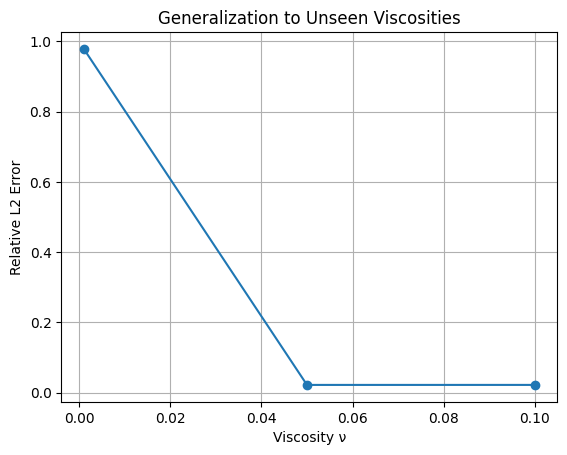

In [40]:
plt.plot(nus, errors, marker='o')
plt.xlabel("Viscosity ν")
plt.ylabel("Relative L2 Error")
plt.title("Generalization to Unseen Viscosities")
plt.grid(True)
plt.show()

Train Size =  100 | Relative L2 Error = 0.14996
Train Size =  200 | Relative L2 Error = 0.07425
Train Size =  500 | Relative L2 Error = 0.04476
Train Size = 1000 | Relative L2 Error = 0.02727


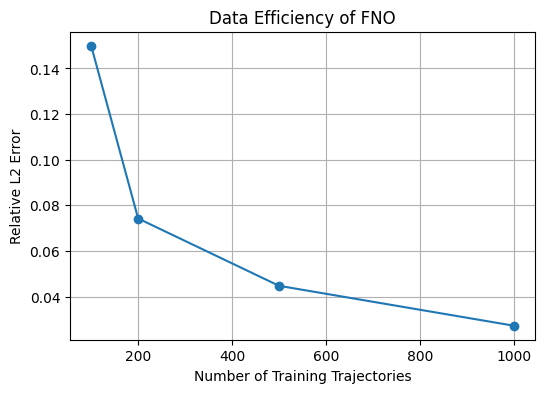

In [ ]:
train_sizes = [100, 200, 500, 1000]
errors = []

for size in train_sizes:
    # Small training dataset
    train_loader = DataLoader(
        TensorDataset(
            X_train[:size],
            Y_train[:size]
        ),
        batch_size=32,
        shuffle=True,
    )

    # Fresh FNO
    model = FNO(
        n_modes=(16,),
        in_channels=1,
        out_channels=1,
        hidden_channels=64,
        n_layers=4,
        lifting_channel_ratio=2,
        projection_channel_ratio=2,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()

    # Train
    epochs = 30

    for epoch in range(epochs):

        model.train()

        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            pred = model(x_batch)

            loss = criterion(pred, y_batch)

            loss.backward()

            optimizer.step()

    # Evaluate
    model.eval()

    with torch.no_grad():

        pred = model(X_test.to(device)).cpu()

    error = torch.norm(pred - Y_test) / torch.norm(Y_test)

    errors.append(error.item())

    print(f"Train Size = {size:4d} | Relative L2 Error = {error:.5f}")

# Plot
plt.figure(figsize=(6,4))

plt.plot(train_sizes, errors, marker='o')

plt.xlabel("Number of Training Trajectories")
plt.ylabel("Relative L2 Error")
plt.title("Data Efficiency of FNO")
plt.grid(True)

plt.show()

In [ ]:
# #Discussion: When to choose Neural Operator over per-instance PINN?
# The neural operator is useful when we need to solve the same PDE under different initial/boundary conditions. While the process of training the neural operator may take time (data generation + training),
# once the model is trained, it can give us a solution for new inputs virtually instantly. At the same time, in case of a PINN, training of the model is needed every time a new problem arises and this will make it considerably slower.
# For a single PDE or in cases where little data is provided, a PINN is usually a preferable option due to the fact that we do not have to deal with the generation of pre-training data.
# However, in cases where the goal is to solve the same type of PDE several times, a neural operator is more efficient.